In [10]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [11]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]

In [12]:
analysis_path = Path(validation_path) / "analysis"

agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [13]:
drop_columns=["monthly_data_id","unit_id"]
# multiply all other columns by population_scale_from_input_yml to get the actual population
for col in agg_population.columns:
    if col not in drop_columns:
        agg_population[col] /= population_scale_from_input_yml

In [14]:
agg_population["mean_population"] = agg_population.drop(columns=["monthly_data_id","unit_id"]).mean(axis=1).astype(int)
agg_population

,monthly_data_id,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,...,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,1,5354156.0,5354080.0,5354056.0,5354172.0,5354124.0,5354124.0,5354204.0,5354112.0,...,5354112.0,5354120.0,5354128.0,5354128.0,5354064.0,5354136.0,5354160.0,5354112.0,5354012.0,5354119
1,1,2,3319840.0,3319844.0,3319844.0,3319872.0,3319832.0,3319736.0,3319868.0,3319864.0,...,3319804.0,3319880.0,3319884.0,3319852.0,3319832.0,3319872.0,3319836.0,3319848.0,3319848.0,3319845
2,1,3,2720768.0,2720780.0,2720856.0,2720708.0,2720684.0,2720760.0,2720748.0,2720852.0,...,2720772.0,2720732.0,2720728.0,2720804.0,2720804.0,2720788.0,2720736.0,2720772.0,2720760.0,2720768
3,1,4,2303184.0,2303168.0,2303256.0,2303180.0,2303268.0,2303288.0,2303132.0,2303260.0,...,2303240.0,2303232.0,2303208.0,2303232.0,2303252.0,2303200.0,2303212.0,2303192.0,2303268.0,2303223
4,1,5,3941384.0,3941376.0,3941424.0,3941344.0,3941384.0,3941380.0,3941404.0,3941396.0,...,3941332.0,3941312.0,3941320.0,3941392.0,3941408.0,3941448.0,3941316.0,3941404.0,3941432.0,3941380
5,1,6,2709432.0,2709408.0,2709412.0,2709444.0,2709412.0,2709468.0,2709412.0,2709356.0,...,2709432.0,2709496.0,2709408.0,2709372.0,2709420.0,2709448.0,2709464.0,2709424.0,2709360.0,2709416
6,2,1,5365128.0,5363740.0,5364680.0,5365728.0,5363556.0,5365832.0,5364740.0,5363684.0,...,5363964.0,5364360.0,5364500.0,5365488.0,5365292.0,5363464.0,5363588.0,5364600.0,5363716.0,5364550
7,2,2,3309956.0,3310144.0,3309612.0,3310112.0,3310404.0,3309360.0,3309000.0,3309112.0,...,3309064.0,3309432.0,3309488.0,3309180.0,3308924.0,3310664.0,3308936.0,3308272.0,3309168.0,3309460
8,2,3,2707668.0,2707768.0,2706080.0,2706296.0,2706920.0,2708052.0,2707696.0,2707152.0,...,2706924.0,2707852.0,2707592.0,2707456.0,2707824.0,2706908.0,2707848.0,2707576.0,2707508.0,2707335
9,2,4,2314776.0,2315184.0,2316312.0,2314556.0,2316104.0,2314700.0,2315708.0,2316352.0,...,2315536.0,2315180.0,2314576.0,2315460.0,2315316.0,2316408.0,2315828.0,2315644.0,2316768.0,2315611


In [15]:
# get total population for each month
population_cols = [col for col in agg_population.columns if col.startswith('population_') or col == 'mean_population']
print(f"Population columns: {population_cols}")
total_population = agg_population.groupby('monthly_data_id')[population_cols].sum(min_count=1).reset_index()
# drop cols with nan values
total_population = total_population.dropna(axis=1, how='any')
total_population.set_index('monthly_data_id')
total_population.to_csv(f"{analysis_path}/total_population_by_month.csv", index=False)
total_population

Population columns: ['population_0', 'population_1', 'population_2', 'population_3', 'population_4', 'population_5', 'population_6', 'population_7', 'population_8', 'population_9', 'population_10', 'population_11', 'population_12', 'population_13', 'population_14', 'population_15', 'population_16', 'population_17', 'population_18', 'population_19', 'mean_population']


,monthly_data_id,population_8,mean_population
0,1,20348724.0,20348751
1,2,20360988.0,20361850
2,3,20348448.0,20349641
3,4,20333280.0,20334806
4,5,20323148.0,20326072
5,6,20319056.0,20322578
6,7,20319716.0,20324154
7,8,20326724.0,20329965
8,9,20336280.0,20336280


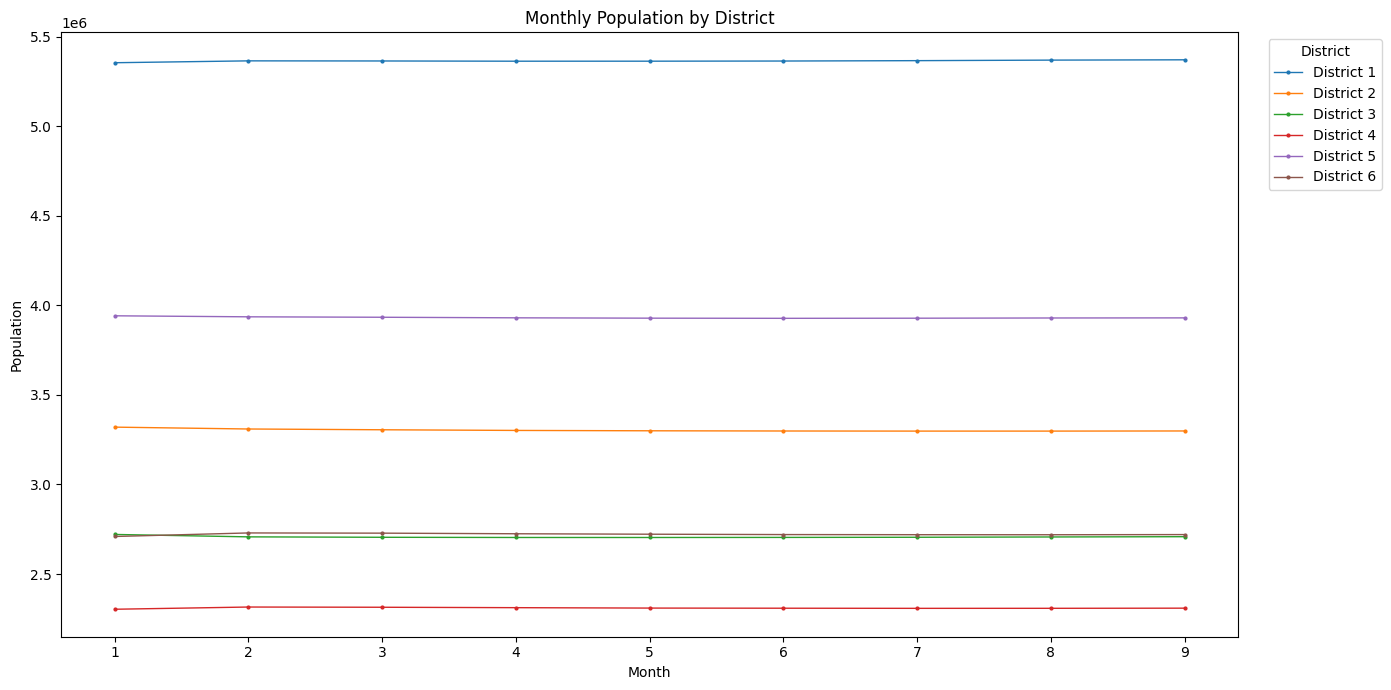

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot one line per district (unit_id), using mean_population as the value
for unit_id, group in agg_population.groupby('unit_id'):
    group_sorted = group.sort_values('monthly_data_id')
    ax.plot(
        group_sorted['monthly_data_id'],
        group_sorted['mean_population'],
        label=f'District {unit_id}',
        marker='o',
        markersize=2,
        linewidth=1
    )

ax.set_xlabel('Month')
ax.set_ylabel('Population')
ax.set_title('Monthly Population by District')
ax.legend(title='District', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

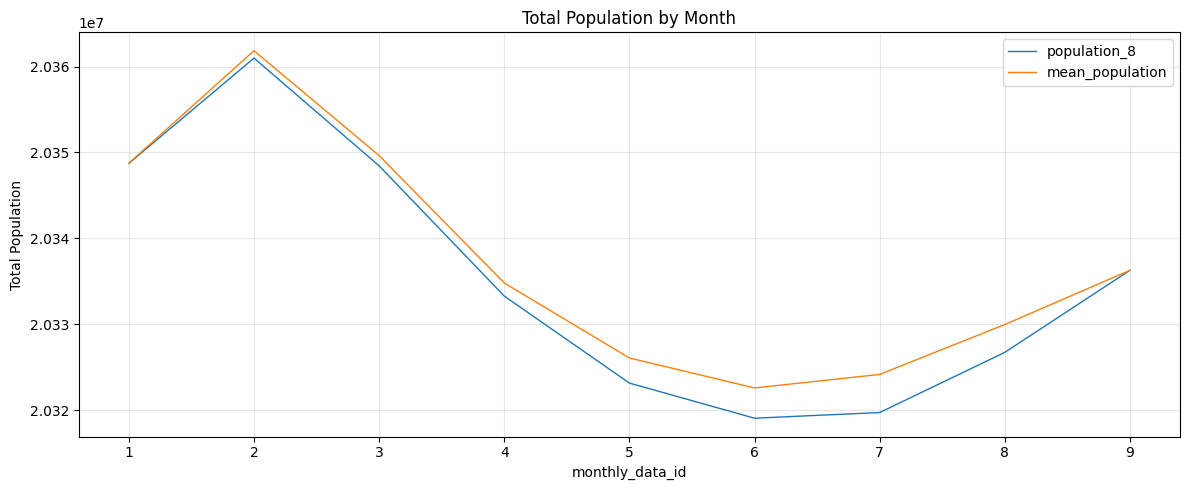

In [17]:
cols = [c for c in total_population.columns if c != 'monthly_data_id']
total_population.plot(
    x='monthly_data_id',
    y=cols,
    figsize=(12, 5),
    legend=True,
    linewidth=1,
    marker=None
)
plt.title("Total Population by Month")
plt.xlabel("monthly_data_id")
plt.ylabel("Total Population")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
total_population

,monthly_data_id,population_8,mean_population
0,1,20348724.0,20348751
1,2,20360988.0,20361850
2,3,20348448.0,20349641
3,4,20333280.0,20334806
4,5,20323148.0,20326072
5,6,20319056.0,20322578
6,7,20319716.0,20324154
7,8,20326724.0,20329965
8,9,20336280.0,20336280
